# Provider Benchmark Results Analysis
Analyzing execution time and memory usage across different providers and configurations.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("provider_results.csv")

try:
    df_single = pd.read_csv("single_rank_results.csv")
    df_single['provider'] = df_single['provider'] + "_SINGLE"
    df = pd.concat([df, df_single], ignore_index=True)
except FileNotFoundError:
    pass

# Only keep successful runs
df = df[df["status"] == "SUCCESS"].copy()

def determine_bind(p):
    if "_SINGLE" in p: return "SINGLE"
    elif "NOBIND" in p: return "NOBIND"
    elif "BIND" in p: return "BIND"
    else: return "OTHER"

df['bind_type'] = df['provider'].apply(determine_bind)
palette = {"BIND": "#4C72B0", "NOBIND": "#C44E52", "OTHER": "#55A868", "SINGLE": "#FF9F00"}

# We DO NOT sort the dataframe here, so it preserves the chronological/loop order from the CSV!

# Display the data information
print("Amount of entries in the dataset:", len(df))

print("Models and their benchmark counts:")
print(df.groupby('model').size())

print("--" * 40)

# Print all entries where the model is "giant"
print("Entries for model 'giant':")
print(df[df['model'] == 'giant'])


Amount of entries in the dataset: 80
Models and their benchmark counts:
model
giant               16
mmcp_transformer    16
perfect             16
transformer         16
watercnn            16
dtype: int64
--------------------------------------------------------------------------------
Entries for model 'giant':
                         label  model                             provider  \
0                    giant_AIX  giant                                  AIX   
5             giant_SS_DEFAULT  giant                           SS_DEFAULT   
10                giant_SS_B96  giant                               SS_B96   
15             giant_SS_NOBIND  giant                            SS_NOBIND   
20    giant_SS_TPQ=2_I=48_B=96  giant                   SS_TPQ=2_I=48_B=96   
25    giant_SS_TPQ=4_I=24_B=96  giant                   SS_TPQ=4_I=24_B=96   
30    giant_SS_TPQ=12_I=8_B=96  giant                   SS_TPQ=12_I=8_B=96   
35    giant_SS_TPQ=24_I=4_B=96  giant                   SS_TPQ

## Execution Time by Model
Each model has its own graph. Colors indicate whether explicit CPU binding (BIND) was used or omitted (NOBIND).

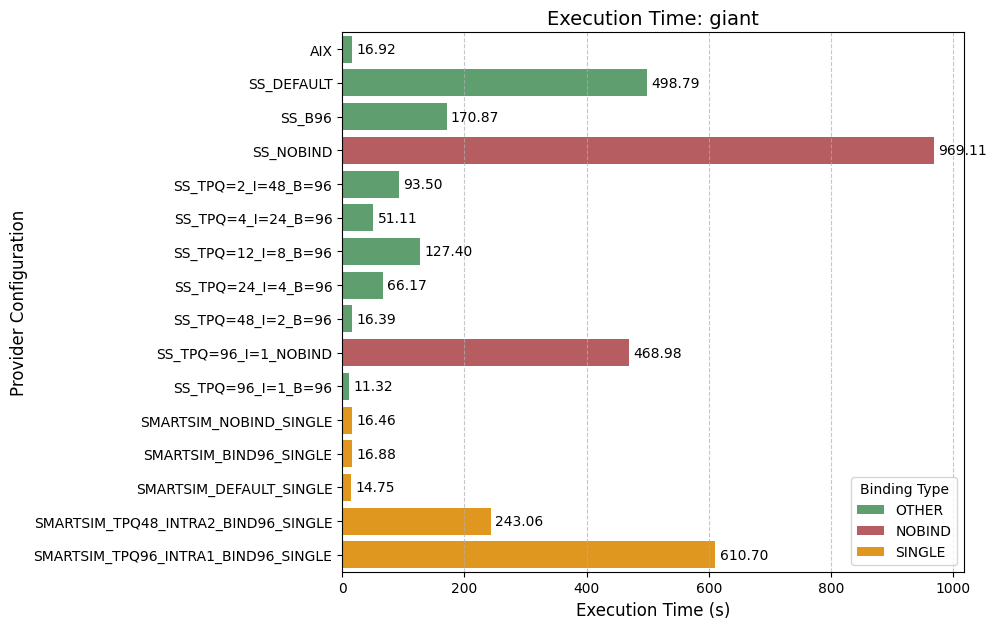

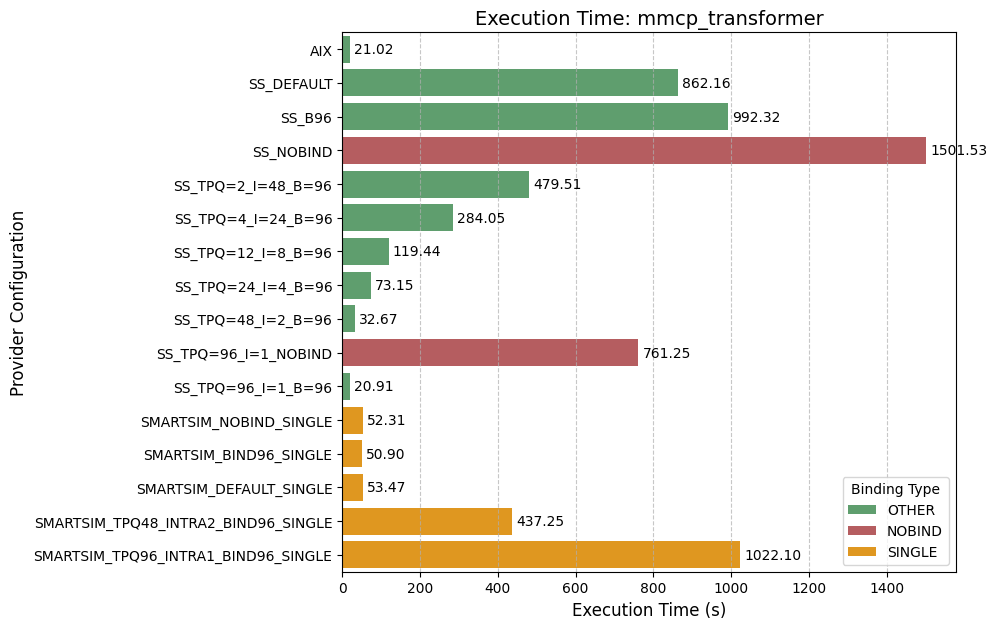

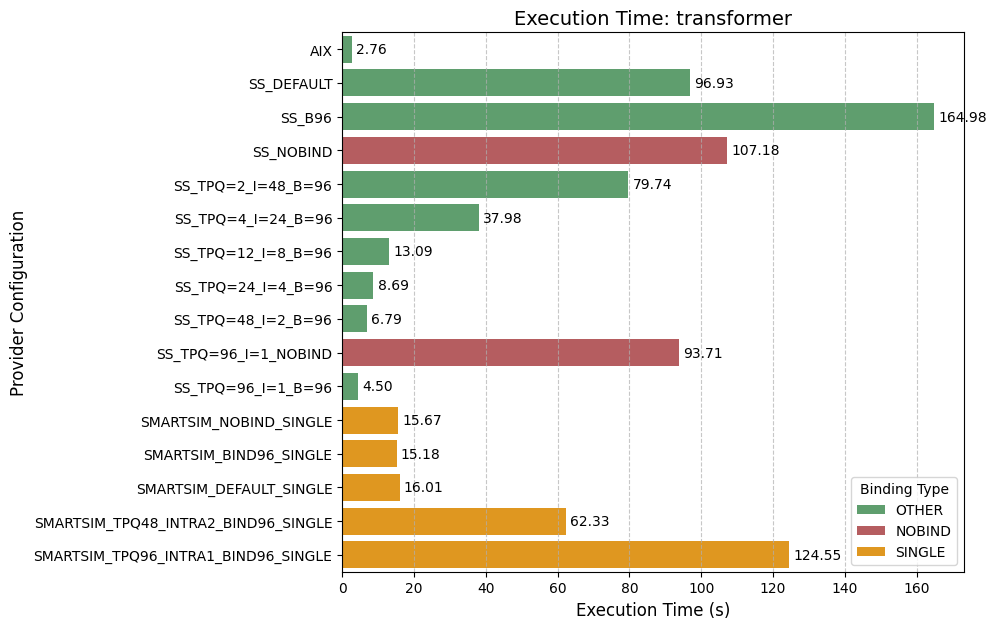

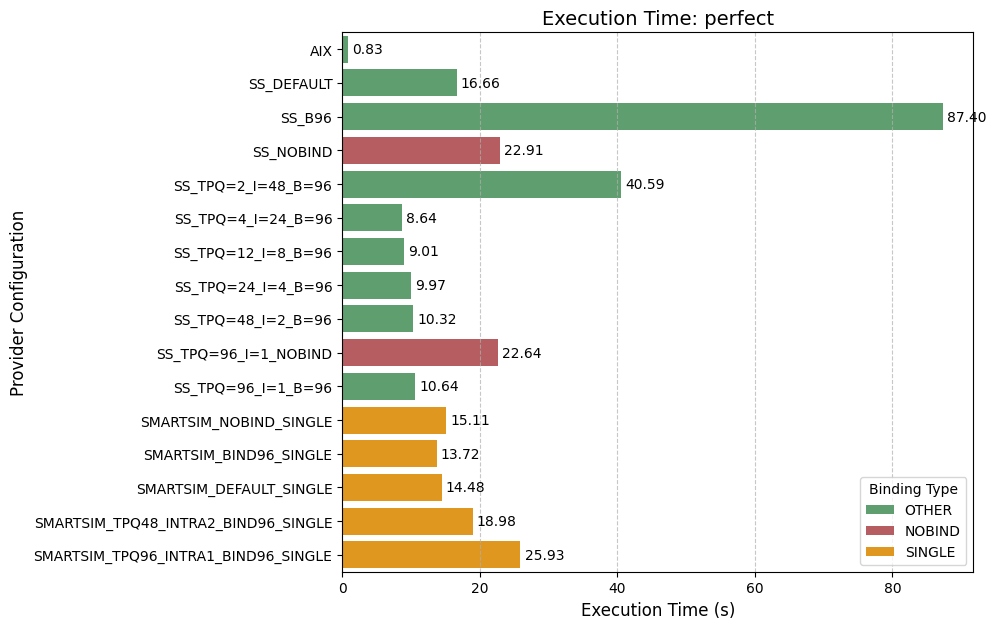

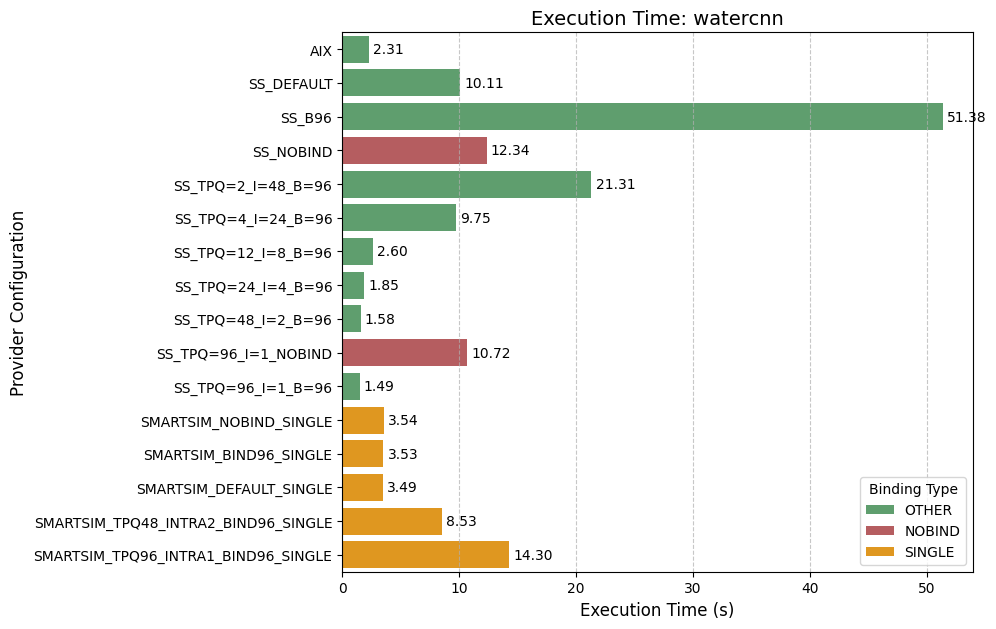

In [25]:
models = df['model'].unique()

for model in models:
    df_model = df[df['model'] == model]
    
    plt.figure(figsize=(10, max(6, len(df_model) * 0.4)))
    ax = sns.barplot(
        data=df_model,
        x="time_s",
        y="provider",
        hue="bind_type",
        palette=palette,
        dodge=False
    )
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",      # adjust formatting as needed
            padding=3
        )

    plt.title(f"Execution Time: {model}", fontsize=14)
    plt.xlabel("Execution Time (s)", fontsize=12)
    plt.ylabel("Provider Configuration", fontsize=12)
    plt.grid(True, axis="x", ls="--", alpha=0.7)
    plt.legend(title="Binding Type", loc="lower right")
    plt.tight_layout()
    plt.show()

## Memory Usage by Model

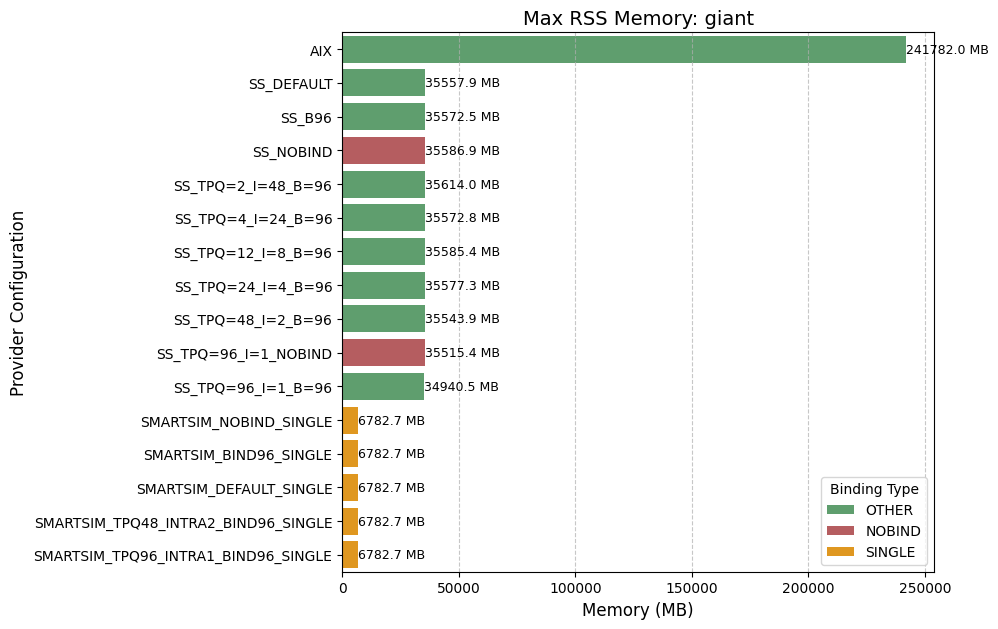

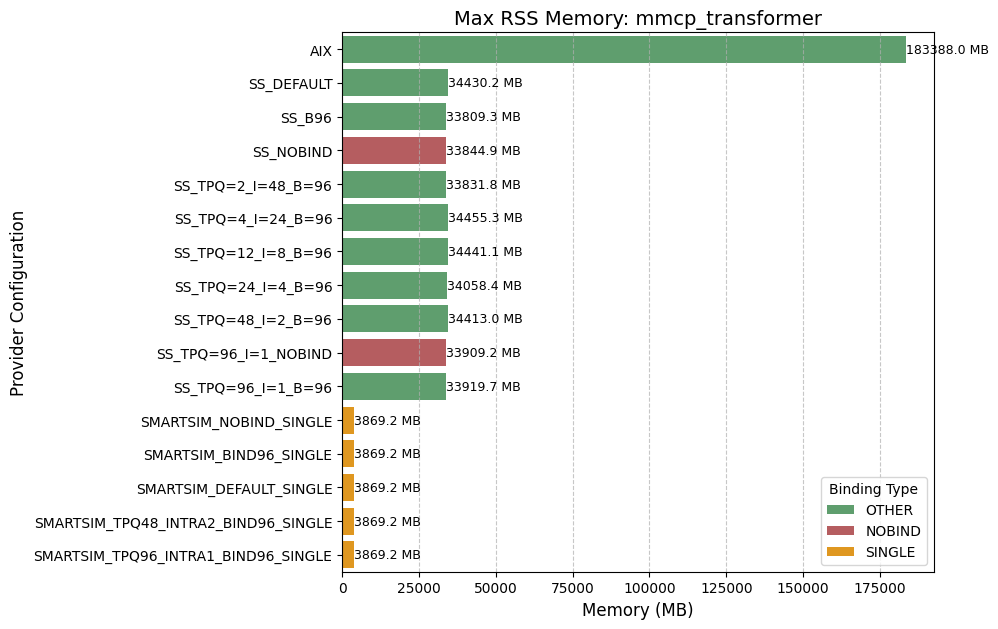

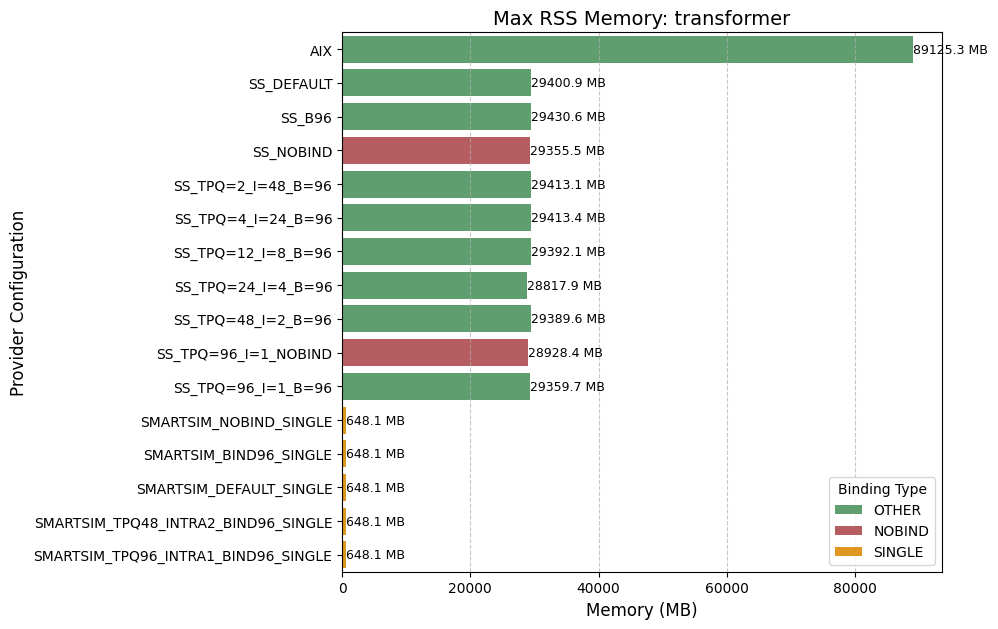

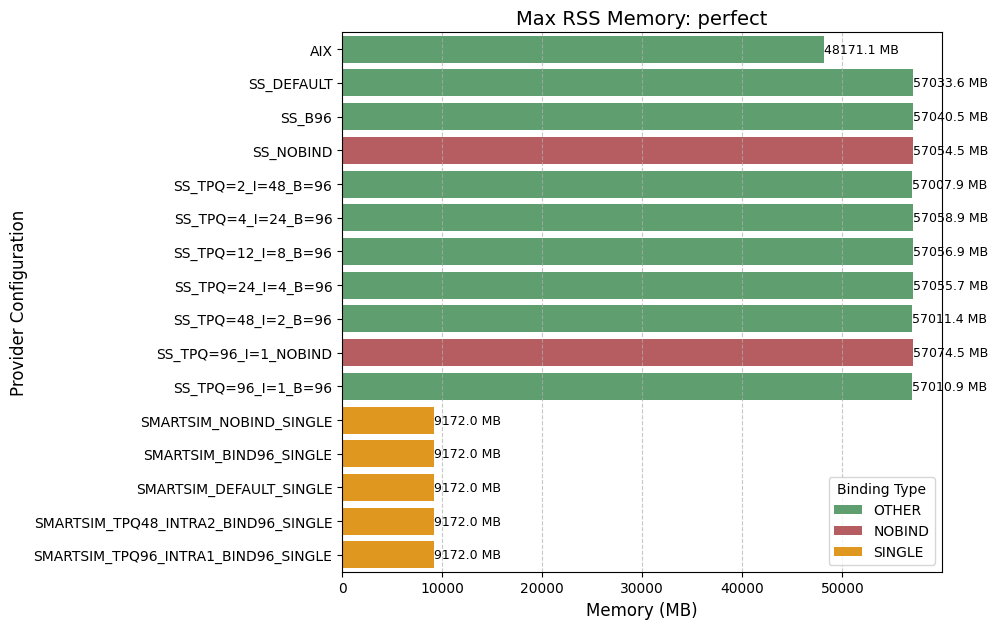

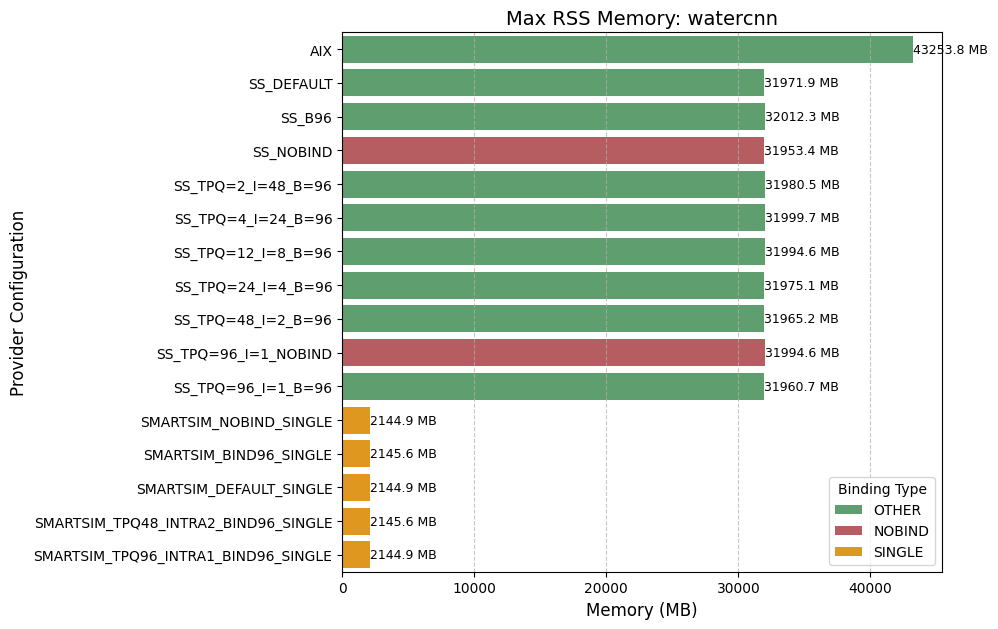

In [26]:
for model in models:
    df_model = df[df['model'] == model]
    
    plt.figure(figsize=(10, max(6, len(df_model) * 0.4)))
    ax = sns.barplot(
        data=df_model,
        x="max_rss_mb",
        y="provider",
        hue="bind_type",
        palette=palette,
        dodge=False
    )

    # Add memory values to bars
    for p in ax.patches:
        width = p.get_width()

        # Skip empty bars
        if abs(width) < 1e-9:
            continue

        y = p.get_y() + p.get_height() / 2

        ax.text(
            width,
            y,
            f"{width:.1f} MB",
            va="center",
            ha="left",
            fontsize=9
        )

    plt.title(f"Max RSS Memory: {model}", fontsize=14)
    plt.xlabel("Memory (MB)", fontsize=12)
    plt.ylabel("Provider Configuration", fontsize=12)
    plt.grid(True, axis="x", ls="--", alpha=0.7)
    plt.legend(title="Binding Type", loc="lower right")
    plt.tight_layout()
    plt.show()